In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.preprocessing import StandardScaler
import os
import globals as gl
from scipy.stats import linregress, t
from pcm_cortical import find_model
import PcmPy as pcm
import pickle
from scipy.stats import ttest_1samp, pearsonr
from matplotlib.patches import ConnectionPatch, Rectangle
from matplotlib import colormaps as cm

plt.style.use('dark_background')

In [ ]:
rois = ['M2', 'M3', 'D3',]
glm = 12
H = 'R'
experiment = 'smp2'

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

vmin, vmax = -.01, .4

fig, axs = plt.subplots(1, len(rois), figsize=(7, 3),sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):

    G_obs = np.load(os.path.join(gl.baseDir, experiment, 'SUIT', gl.pcmDir, f'G_obs.plan.glm{glm}.cerebellum.{H}.{roi}{H}.npy')).mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs)
    D_obs = np.sign(D_obs) * np.sqrt(np.abs(D_obs))

    # Top row: imshow
    im_ax = axs[r]
    cax = im_ax.imshow(D_obs, vmin=vmin, vmax=vmax)
    im_ax.set_xticks(np.arange(5))
    im_ax.set_xticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8, rotation=60, ha='right')
    im_ax.set_title(roi)
    # if r==0:
    im_ax.set_yticks(np.arange(5))
    im_ax.set_yticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8)

bbox = axs[0,].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.006, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('dissimilarity (a.u.)', fontsize=8)

plt.show()

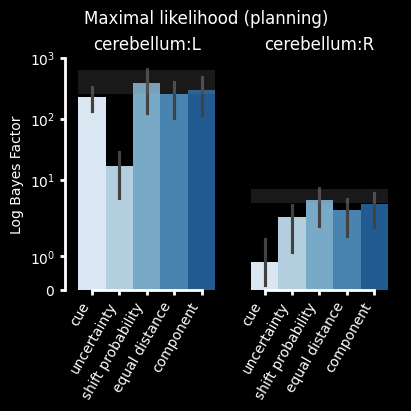

In [28]:
# plt.style.use('dark_background')

Hem = ['L', 'R']
glm = 12
experiment = 'smp2'

fig, axs = plt.subplots(1, len(Hem), figsize=(4, 4), sharex=True, sharey=True, constrained_layout=True)

for r, H in enumerate(Hem):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, 'SUIT', gl.pcmDir, f'T_cv.plan.glm{glm}.cerebellum.{H}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, 'SUIT',gl.pcmDir, f'T_gr.plan.glm{glm}.cerebellum.{H}.p'))

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    width=1,
                    palette='Blues',
                    errorbar='se',
                    plottype='bar')

    ax.set_title(f'cerebellum:{H}')
    ax.set_xlabel('')
    # ax.set_ylim(-1, 2 * 10**3)
    ax.set_ylim(0, 1000)
    # ax.set_yticks([0, 1, 10, 100, 1000])
    ax.set_xlim(-1, 5)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')

    ax.tick_params(width=2, which='both')

    if r == 0:
        ax.spines[['top', 'right',]].set_visible(False)
        ax.spines[['bottom','left']].set_linewidth(2)
        # ax.spines[['left',]].set_bounds([0, 1000])
        ax.spines[['bottom',]].set_bounds([0, 4])
    else:
        ax.spines[['top', 'right','left']].set_visible(False)
        ax.spines[['bottom']].set_linewidth(2)
        ax.spines[['bottom',]].set_bounds([0, 4])
        ax.tick_params(axis='y', width=0, which='both')

for ax in axs:
    ax.set_yscale('symlog')

fig.suptitle('Maximal likelihood (planning)')

plt.show()

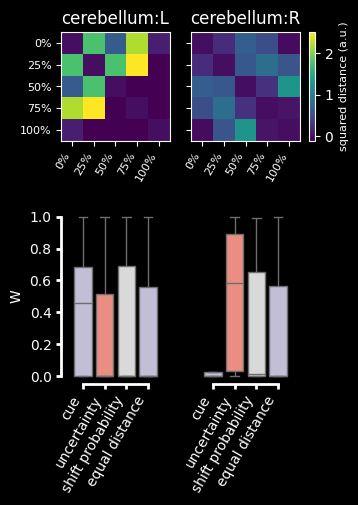

In [29]:
Hem = ['L', 'R']
glm = 12
experiment = 'smp2'

features = np.array(['cue', 'uncertainty', 'shift probability','equal distance'])

Mf, idx = find_model(os.path.join(gl.baseDir, experiment,'SUIT', gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

vmin, vmax = -.1, 2.5

colors = sns.color_palette("Set3", n_colors=9) #+ [(.5, .5, .5)]
colors = [colors[2], colors[3], colors[8]]  # match color used for execution

fig, axs = plt.subplots(2, len(Hem), figsize=(3, 5), sharey='row')

for r, H in enumerate(Hem):

    G_obs = np.load(os.path.join(gl.baseDir, experiment,'SUIT', gl.pcmDir, f'G_obs.plan.glm{glm}.cerebellum.{H}.npy')).mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs / np.trace(G_obs))

    # Top row: imshow
    im_ax = axs[0, r]
    cax = im_ax.imshow(D_obs, vmin=vmin, vmax=vmax)
    im_ax.set_xticks(np.arange(5))
    im_ax.set_xticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8, rotation=60, ha='right')
    im_ax.set_title(f'cerebellum:{H}')
    if r==0:
        im_ax.set_yticks(np.arange(5))
        im_ax.set_yticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8)

    # Bottom row: bar plot
    row_ax = axs[1, r]
    f = open(os.path.join(gl.baseDir, experiment, 'SUIT', gl.pcmDir, f'theta_in.plan.glm{glm}.cerebellum.{H}.p'), "rb")
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta_exp = np.exp(theta)
    theta_sqrt = np.sqrt(theta_exp)
    theta_scaled = theta_sqrt / np.linalg.norm(theta_sqrt, axis=0, keepdims=True)
    theta_avg = theta_scaled.mean(axis=1)
    theta_err = theta_scaled.std(axis=1) / np.sqrt(theta_scaled.shape[1])

    df = pd.DataFrame(theta_scaled.T, columns=features)

    sns.boxplot(data=df, ax=row_ax, palette=colors, showfliers=False, width = .8)
    row_ax.set_xticks(row_ax.get_xticks())
    row_ax.set_xticklabels(features, rotation=60, ha='right')
    row_ax.spines[['top', 'right']].set_visible(False)
    row_ax.set_xlim((-1, 4))
    row_ax.spines[['left',]].set_bounds(0, 1)
    row_ax.spines[['bottom',]].set_bounds(0, 3)
    if r == 0:
        row_ax.set_ylabel('W')
        row_ax.spines[['left', 'bottom']].set_linewidth(2)
        row_ax.tick_params(width=2)
    else:
        row_ax.spines[['top', 'right', 'left']].set_visible(False)
        row_ax.spines[['bottom']].set_linewidth(2)
        row_ax.tick_params('x', width=2)
        row_ax.tick_params('y', width=0)

# Colorbar for imshow (top row)
fig.subplots_adjust(right=0.92)
bbox = axs[0, 0].get_position()
cbar_ax = fig.add_axes([0.95, bbox.y0, 0.02, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('squared distance (a.u.)', fontsize=8)

plt.show()

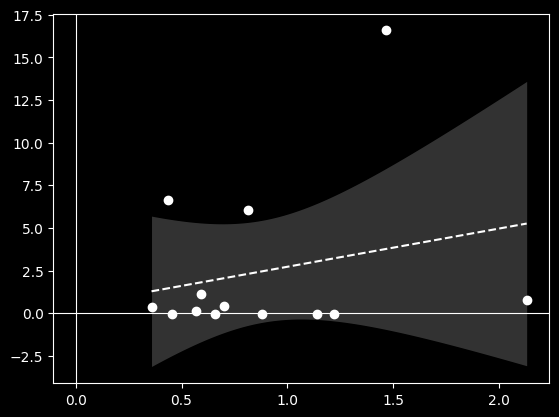

In [37]:
snS = ['102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114']

df = pd.DataFrame()
for sn in snS:
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df, df_tmp])
df.stimFinger = df.stimFinger.map(gl.stimFinger_mapping)
df.cue = df.cue.map(gl.cue_mapping)
df = df[((df.stimFinger=='index') & (df.cue=='75%')) | ((df.stimFinger=='ring') & (df.cue=='25%'))]
df = df.groupby(['sn']).mean(numeric_only=True).reset_index()

T_in = pd.read_pickle(os.path.join(gl.baseDir, experiment, 'SUIT', gl.pcmDir, f'T_in.plan.glm{glm}.cerebellum.R.p'))

Mf, idx = find_model(os.path.join(gl.baseDir, experiment,'SUIT', gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param
f = open(os.path.join(gl.baseDir, experiment, 'SUIT', gl.pcmDir, f'theta_in.plan.glm{glm}.cerebellum.R.p'), "rb")
params = pickle.load(f)[idx]
theta = params[:n_param]
theta_exp = np.exp(theta)
theta_sqrt = np.sqrt(theta_exp)
theta_scaled = theta_sqrt / np.linalg.norm(theta_sqrt, axis=0, keepdims=True)

x = df['MD']
y = T_in['likelihood']['uncertainty'] - T_in['likelihood']['null']
slope, intercept, r_value, p_value, std_err = linregress(x, y)

x_fit = np.linspace(np.min(x), np.max(x), 100)
y_fit = slope * x_fit + intercept

# Compute confidence intervals
n = len(x)
y_pred = slope * x + intercept
residuals = y - y_pred
dof = n - 2
t_val = t.ppf(0.975, dof)

se_line = np.sqrt(
    np.sum(residuals**2) / dof * (1/n + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
)
ci = t_val * se_line

fig, ax = plt.subplots()

ax.plot(x_fit, y_fit, color='w', linestyle='--', label='Fit')
ax.fill_between(x_fit, y_fit - ci, y_fit + ci, color='w', alpha=.2, label='95% CI', lw=0)
ax.scatter(x, y, color='w')

ax.axvline(0, lw=.8, color='w')
ax.axhline(0, lw=.8, color='w')

plt.show()